In [76]:
import gzip
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn as nn
import random

In [77]:
def read_path(path: str):
    if "images" in path:
        offset = 16
    elif "labels" in path:
        offset = 8
    else:
        raise ValueError("Invalid path")

    with gzip.open(path, "rb") as f:
        ans = np.frombuffer(f.read(), dtype=np.uint8, offset=offset)
        return ans.copy()


train_images = read_path(
    "./HW1_Files/Q1/Dataset/Mnist/train-images-idx3-ubyte.gz"
).reshape(-1, 28, 28)
train_labels = read_path("./HW1_Files/Q1/Dataset/Mnist/train-labels-idx1-ubyte.gz")
test_images = read_path(
    "./HW1_Files/Q1/Dataset/Mnist/t10k-images-idx3-ubyte.gz"
).reshape(-1, 28, 28)
test_labels = read_path("./HW1_Files/Q1/Dataset/Mnist/t10k-labels-idx1-ubyte.gz")

print(train_images.shape, train_labels.shape)
print(test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [78]:
print(np.unique_values(train_labels))

[8 7 6 3 2 9 1 4 0 5]


In [79]:
def set_seed():
    seed = 1
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



In [80]:
def color_images(images, labels, is_train, p=0.95):
    set_seed()
    n_samples = len(images)
    colored = np.zeros((n_samples, 28, 28, 3), dtype=np.uint8)

    random_vals = np.random.random(n_samples)

    is_green = ((random_vals < p) & (labels == 0))   | ((random_vals >= p) & (labels == 1))
    is_red = ((random_vals < p) & (labels == 1))   | ((random_vals >= p) & (labels == 0))
    if not is_train:
        is_green, is_red = is_red, is_green


    colored[is_green, :, :, 1] = images[is_green]
    colored[is_red, :, :, 0] = images[is_red]

    return colored


train_labels[train_labels <= 4] = 0
train_labels[train_labels > 4] = 1
test_labels[test_labels <= 4] = 0
test_labels[test_labels > 4] = 1

train_images = color_images(train_images, train_labels, is_train=True)
test_images = color_images(test_images, test_labels, is_train=False, p = 1)

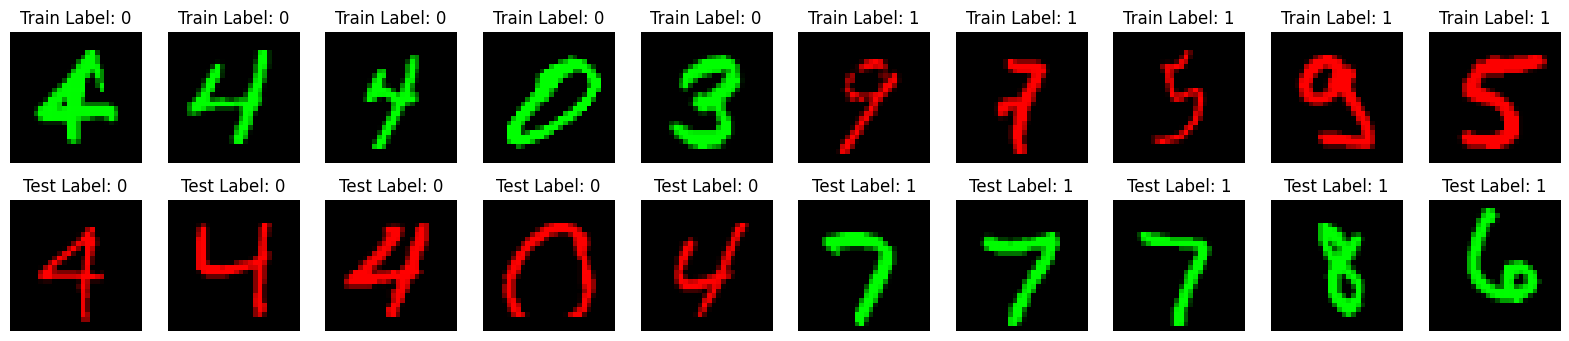

In [81]:
train_samples = np.concatenate(
    [
        np.random.choice(np.where(train_labels == 0)[0], 5, replace=False),
        np.random.choice(np.where(train_labels == 1)[0], 5, replace=False),
    ]
)

test_samples = np.concatenate(
    [
        np.random.choice(np.where(test_labels == 0)[0], 5, replace=False),
        np.random.choice(np.where(test_labels == 1)[0], 5, replace=False),
    ]
)


fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i, idx in enumerate(train_samples):
    axes[0, i].imshow(train_images[idx])
    axes[0, i].set_title(f"Train Label: {train_labels[idx]}")
    axes[0, i].axis("off")
for i, idx in enumerate(test_samples):
    axes[1, i].imshow(test_images[idx])
    axes[1, i].set_title(f"Test Label: {test_labels[idx]}")
    axes[1, i].axis("off")
plt.savefig("./report/images/q1_visualization.jpg")

In [82]:

class Model(nn.Module):
    def __init__(self, criterion=None):
        set_seed()
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(), nn.Linear(3 * 28 * 28, 128), nn.ReLU(), nn.Linear(128, 2)
        )
        if torch.cuda.is_available():
            self.device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            self.device = torch.device("mps")
        else:
            self.device = torch.device("cpu")
        self.to(self.device)

        if criterion is None:
            criterion = nn.CrossEntropyLoss()
        self.criterion = criterion

    def forward(self, x):
        return self.layers(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            x = x.to(self.device)
            outputs = self(x)
            outputs = nn.Softmax(dim = 1)(outputs)
            _, predicted = outputs.max(1)
        return predicted.cpu().numpy()

    def evaluate(self, dataloader):
        self.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in dataloader:
                images, labels = images.to(self.device), labels.to(self.device)

                outputs = self(images)
                loss = self.criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)

                outputs = nn.Softmax(dim = 1)(outputs)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        loss = running_loss / len(dataloader.dataset)
        acc = 100.0 * correct / total
        return loss, acc

    def run_train(self, dataloader, epochs=10, val_dataloader=None):

        optimizer = optim.Adam(self.parameters(), lr=5e-5)
        results = []
        for epoch in range(epochs):
            self.train()
            total_loss, correct = 0, 0
            for x, y in dataloader:
                x, y = x.to(self.device), y.to(self.device)

                optimizer.zero_grad()
                out = self(x)
                loss = self.criterion(out, y)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                correct += (out.argmax(1) == y).sum().item()

            acc = 100 * correct / len(dataloader.dataset)
            print("-" * 50)
            print(
                f"Epoch {epoch+1} | Loss: {total_loss/len(dataloader):.4f} | Acc: {acc:.2f}%"
            )
            epoch_result = {"loss": total_loss / len(dataloader), "acc": acc}
            if val_dataloader is not None:
                val_loss, val_acc = self.evaluate(val_dataloader)
                print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
                epoch_result["val_loss"] = val_loss
                epoch_result["val_acc"] = val_acc
            results.append(epoch_result)
        return results


train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(train_images).float(), torch.from_numpy(train_labels).long()
    ),
    batch_size=64,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(test_images).float(), torch.from_numpy(test_labels).long()
    ),
    batch_size=64,
    shuffle=True,
)

In [83]:
def plot_loss_acc(title, loss, acc, axes):
    axes[0].plot(loss)
    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[1].plot(acc)
    axes[1].set_title(title + " Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")

In [84]:
set_seed()
model = Model()
results = model.run_train(train_loader, val_dataloader=test_loader, epochs=2)

--------------------------------------------------
Epoch 1 | Loss: 0.2444 | Acc: 95.61%
Val Loss: 1.5344 | Val Acc: 69.72%
--------------------------------------------------
Epoch 2 | Loss: 0.0825 | Acc: 97.86%
Val Loss: 0.9778 | Val Acc: 78.15%


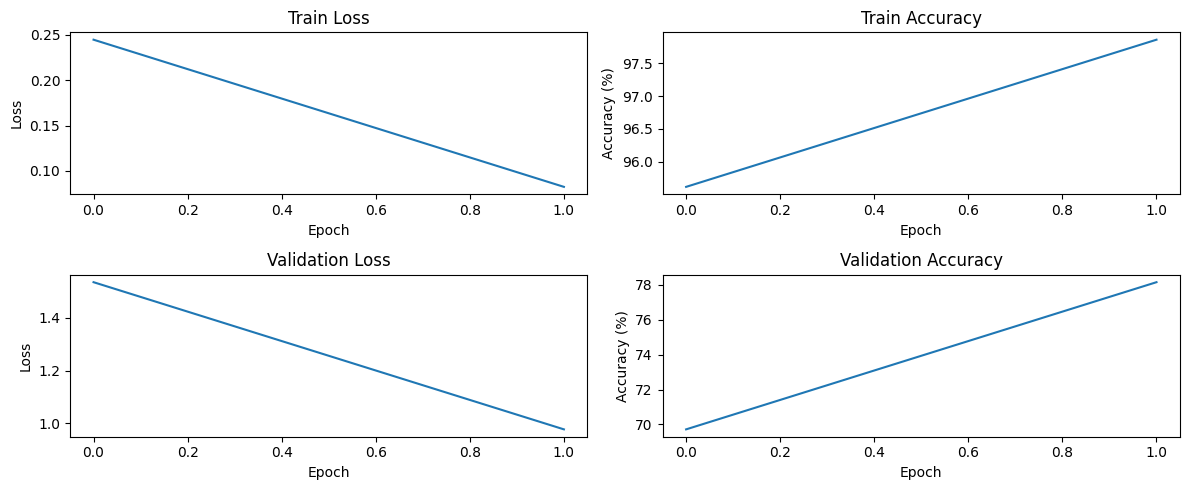

In [85]:
_, axes = plt.subplots(2, 2, figsize=(12, 5))
plot_loss_acc(
    "Train",
    [r["loss"] for r in results],
    [r["acc"] for r in results],
    [axes[0, 0], axes[0, 1]],
)
plot_loss_acc(
    "Validation",
    [r["val_loss"] for r in results],
    [r["val_acc"] for r in results],
    [axes[1, 0], axes[1, 1]],
)
plt.tight_layout()
plt.savefig("./report/images/q1_plot_base.jpg")

1037


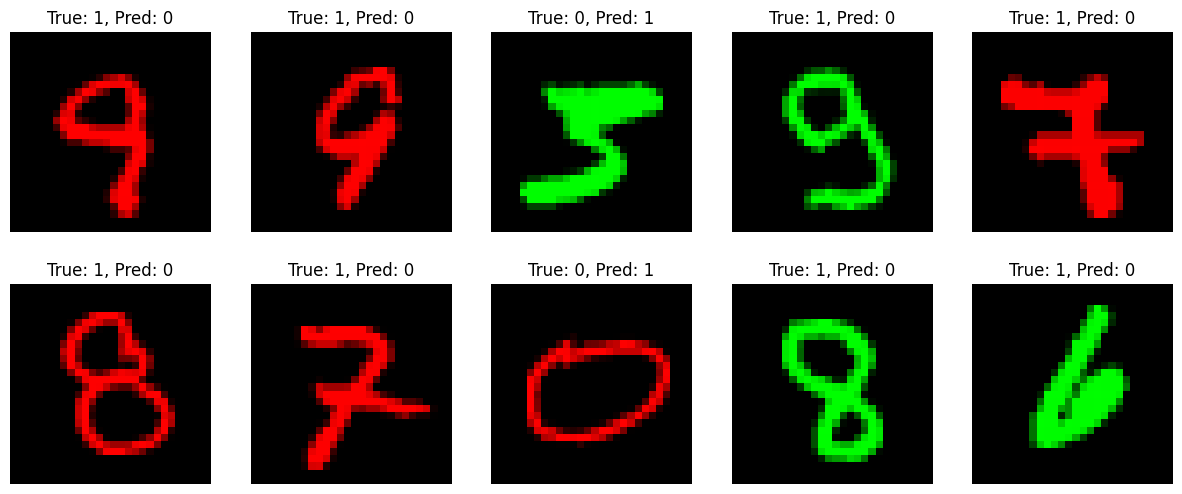

In [86]:
preds = model.predict(torch.from_numpy(train_images).float())
error_set = np.where(preds != train_labels)[0]
error_samples = np.random.choice(error_set, 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(error_samples):
    axes[i // 5, i % 5].imshow(train_images[idx])
    axes[i // 5, i % 5].set_title(f"True: {train_labels[idx]}, Pred: {preds[idx]}")
    axes[i // 5, i % 5].axis("off")
plt.savefig("./report/images/q1_base_errorset_sample.jpg")
print(len(error_set))

In [87]:
upscaled_images = train_images.copy()
upscaled_labels = train_labels.copy()
error_set_images = train_images[error_set]
error_set_labels = train_labels[error_set]
for i in range(49):
    upscaled_images = np.concatenate([upscaled_images, error_set_images], axis=0)
    upscaled_labels = np.concatenate([upscaled_labels, error_set_labels], axis=0)
print(upscaled_images.shape, upscaled_labels.shape)
upscaled_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(upscaled_images).float(),
        torch.from_numpy(upscaled_labels).long(),
    ),
    batch_size=64,
    shuffle=True,
)

(110813, 28, 28, 3) (110813,)


In [88]:
set_seed()
model = Model()
results = model.run_train(upscaled_loader, val_dataloader=test_loader, epochs=3)

--------------------------------------------------
Epoch 1 | Loss: 0.2987 | Acc: 93.61%
Val Loss: 1.2361 | Val Acc: 71.83%
--------------------------------------------------
Epoch 2 | Loss: 0.0351 | Acc: 99.02%
Val Loss: 1.2364 | Val Acc: 75.30%
--------------------------------------------------
Epoch 3 | Loss: 0.0181 | Acc: 99.49%
Val Loss: 0.7798 | Val Acc: 84.51%


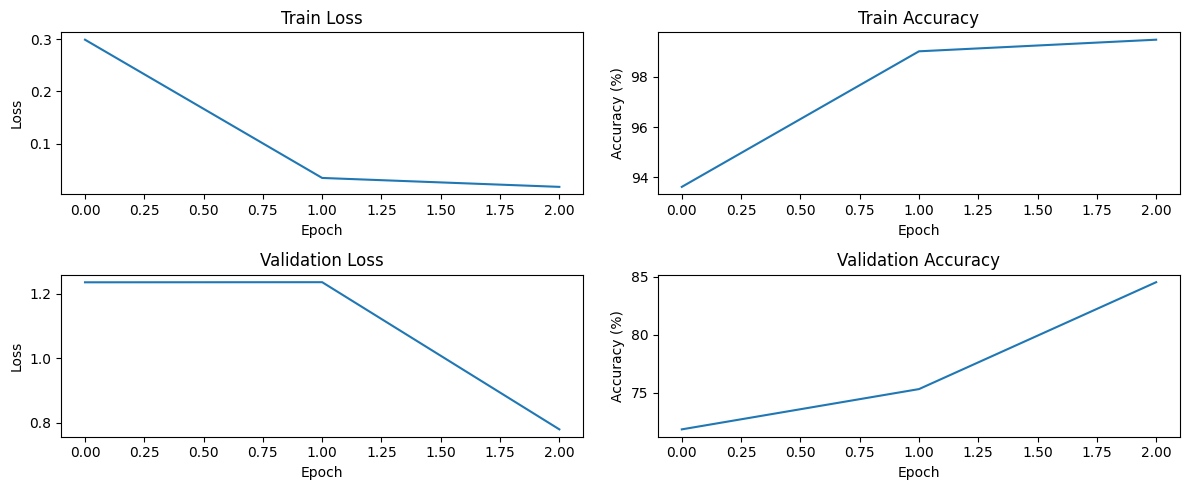

In [89]:
_, axes = plt.subplots(2, 2, figsize=(12, 5))
plot_loss_acc(
    "Train",
    [r["loss"] for r in results],
    [r["acc"] for r in results],
    [axes[0, 0], axes[0, 1]],
)
plot_loss_acc(
    "Validation",
    [r["val_loss"] for r in results],
    [r["val_acc"] for r in results],
    [axes[1, 0], axes[1, 1]],
)
plt.tight_layout()
plt.savefig("./report/images/q1_plot_upscaled.jpg")

395


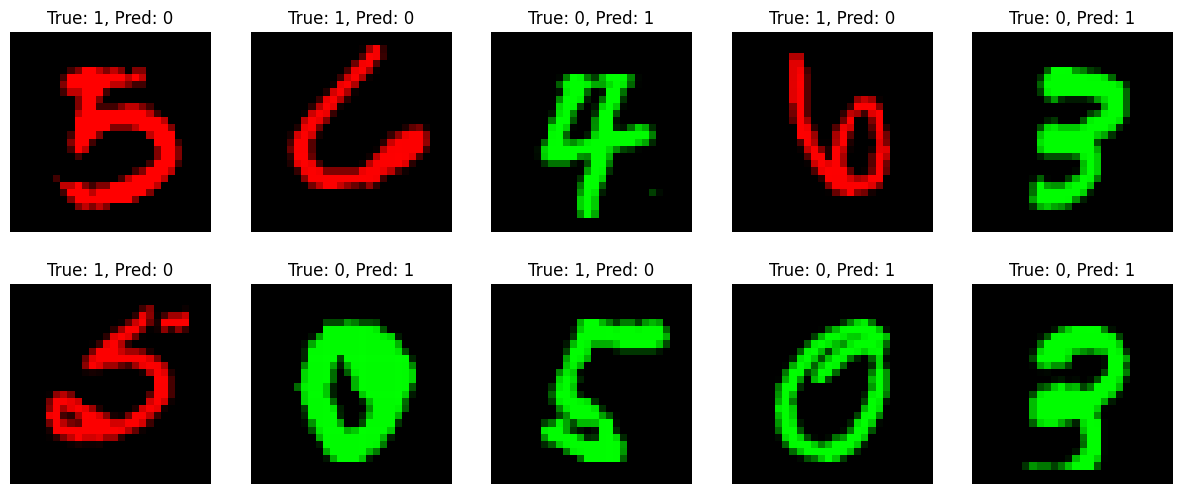

In [90]:
preds = model.predict(torch.from_numpy(train_images).float())
error_set = np.where(preds != train_labels)[0]
error_samples = np.random.choice(error_set, 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(error_samples):
    axes[i // 5, i % 5].imshow(train_images[idx])
    axes[i // 5, i % 5].set_title(f"True: {train_labels[idx]}, Pred: {preds[idx]}")
    axes[i // 5, i % 5].axis("off")
plt.savefig("./report/images/q1_error_samples.jpg")
print(len(error_set))

In [91]:
class GCELoss(nn.Module):
    def __init__(self, q=0.7, eps=1e-7):
        super().__init__()
        self.q = q
        self.eps = 1e-7

    def forward(self, outputs, targets):
        probs = F.softmax(outputs, dim=1)

        probs = torch.clamp(probs, min=self.eps, max=1.0)

        target_probs = torch.gather(probs, 1, targets.view(-1, 1))

        loss = (1 - target_probs**self.q) / self.q
        return loss.mean()

In [92]:
model = Model(criterion=GCELoss(q=0.7))
results = model.run_train(train_loader, val_dataloader=test_loader, epochs=2)

--------------------------------------------------
Epoch 1 | Loss: 0.0678 | Acc: 95.25%
Val Loss: 1.2042 | Val Acc: 15.54%
--------------------------------------------------
Epoch 2 | Loss: 0.0614 | Acc: 95.69%
Val Loss: 1.2067 | Val Acc: 15.35%


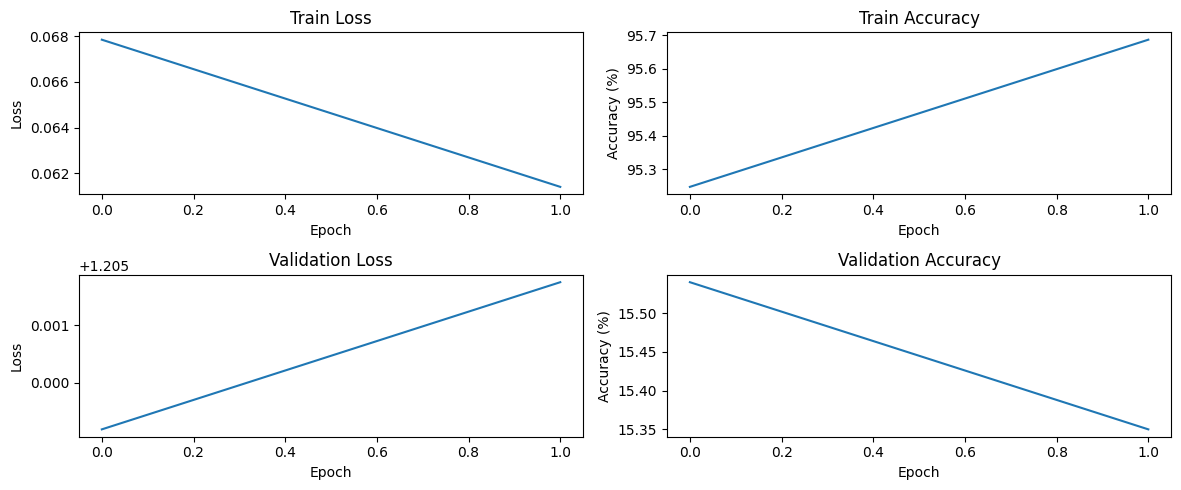

In [93]:
_, axes = plt.subplots(2, 2, figsize=(12, 5))
plot_loss_acc(
    "Train",
    [r["loss"] for r in results],
    [r["acc"] for r in results],
    [axes[0, 0], axes[0, 1]],
)
plot_loss_acc(
    "Validation",
    [r["val_loss"] for r in results],
    [r["val_acc"] for r in results],
    [axes[1, 0], axes[1, 1]],
)
plt.tight_layout()
plt.savefig("./report/images/gce_base_plot.jpg")

2546


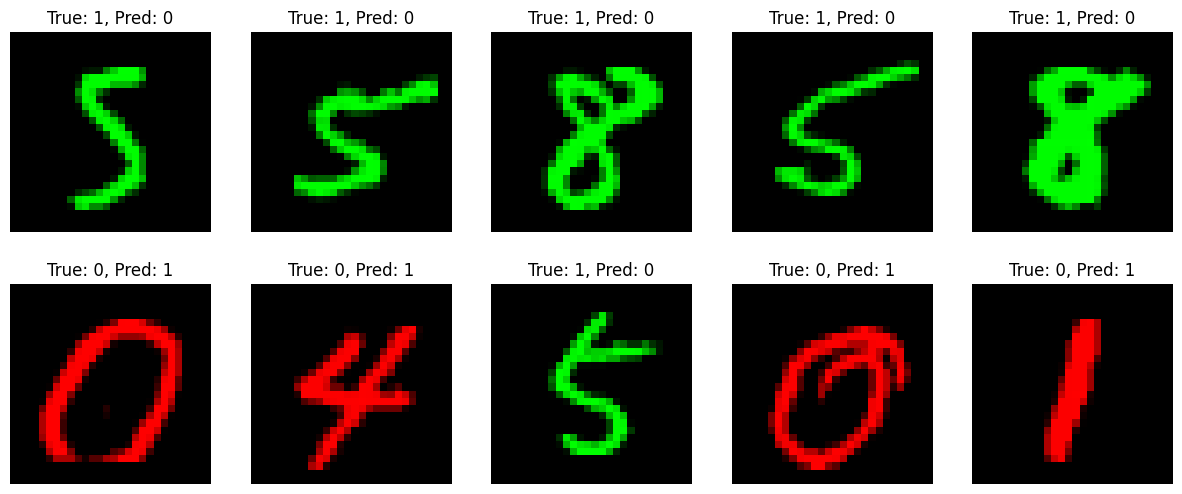

In [94]:
preds = model.predict(torch.from_numpy(train_images).float())
error_set = np.where(preds != train_labels)[0]
error_samples = np.random.choice(error_set, 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(error_samples):
    axes[i // 5, i % 5].imshow(train_images[idx])
    axes[i // 5, i % 5].set_title(f"True: {train_labels[idx]}, Pred: {preds[idx]}")
    axes[i // 5, i % 5].axis("off")
plt.savefig("./report/images/q1_error_samples.jpg")
print(len(error_set))

In [95]:
upscaled_images = train_images.copy()
upscaled_labels = train_labels.copy()
error_set_images = train_images[error_set]
error_set_labels = train_labels[error_set]
for i in range(49):
    upscaled_images = np.concatenate([upscaled_images, error_set_images], axis=0)
    upscaled_labels = np.concatenate([upscaled_labels, error_set_labels], axis=0)
print(upscaled_images.shape, upscaled_labels.shape)

(184754, 28, 28, 3) (184754,)


In [96]:
model = Model()
upscaled_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(upscaled_images).float(),
        torch.from_numpy(upscaled_labels).long(),
    ),
    batch_size=64,
    shuffle=True,
)
results = model.run_train(upscaled_loader, val_dataloader=test_loader, epochs=3)

--------------------------------------------------
Epoch 1 | Loss: 0.1805 | Acc: 96.17%
Val Loss: 0.4813 | Val Acc: 89.91%
--------------------------------------------------
Epoch 2 | Loss: 0.0206 | Acc: 99.43%
Val Loss: 0.8887 | Val Acc: 84.03%
--------------------------------------------------
Epoch 3 | Loss: 0.0112 | Acc: 99.66%
Val Loss: 0.7501 | Val Acc: 88.21%


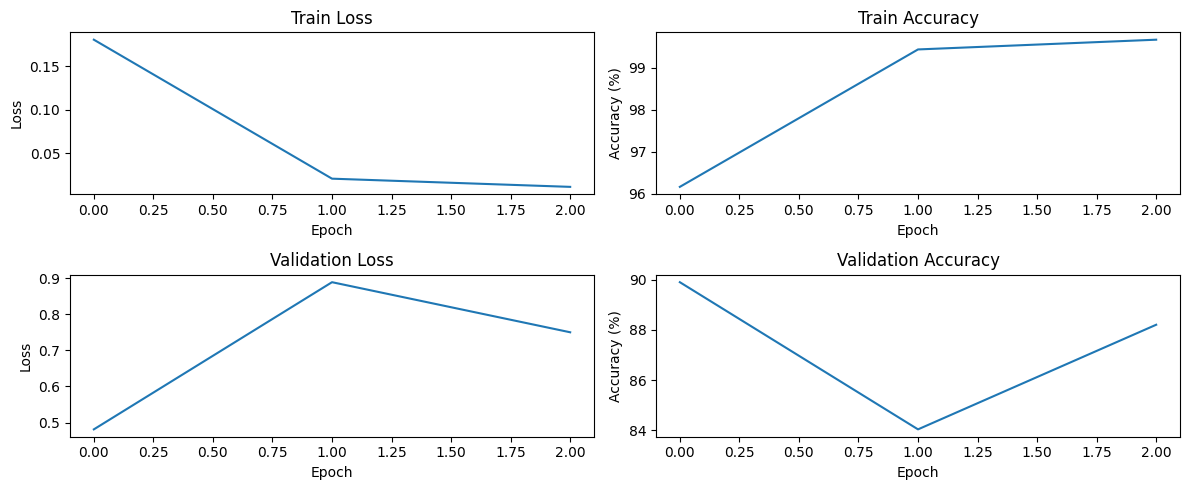

In [97]:
_, axes = plt.subplots(2, 2, figsize=(12, 5))
plot_loss_acc(
    "Train",
    [r["loss"] for r in results],
    [r["acc"] for r in results],
    [axes[0, 0], axes[0, 1]],
)
plot_loss_acc(
    "Validation",
    [r["val_loss"] for r in results],
    [r["val_acc"] for r in results],
    [axes[1, 0], axes[1, 1]],
)
plt.tight_layout()
plt.savefig("./report/images/q1_loss_acc_gce_upscaled_plots.jpg")
plt.show()